# <div align="center"> AirNav Indonesia</div>
---

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os

# Memuat dataset hasil preprocessing
file_path = "SOETTA_MASTER_READY.parquet"
df = pd.read_parquet(file_path)

# Strategi Sampling: Ambil 5 juta record secara random untuk efisiensi training
# Ini biar proses iterasi model lo cepet pas nentuin hyperparameter
df_sample = df.sample(n=5000000, random_state=42).copy()

# Fitur yang digunakan untuk deteksi anomali trajektori
features = ['lat', 'lon', 'alt', 'vertical_rate', 'speed_kmh']

# Normalisasi: Skala 0-1 (Wajib buat Autoencoder agar loss function stabil)
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_sample[features])

print(f"✅ Data Ready: {df_scaled.shape[0]:,} baris untuk fase modeling.")

✅ Data Ready: 5,000,000 baris untuk fase modeling.


# Isolation Forest

In [2]:
# 1. Pilih fitur
features = ['lat', 'lon', 'alt', 'vertical_rate', 'speed_kmh']

# 2. DROP NaN dulu (Kuncinya di sini!)
# Kita buang baris yang salah satu fiturnya ada yang kosong
df_sample = df_sample.dropna(subset=features).copy()

print(f"🧹 Data bersih: {len(df_sample):,} baris siap tempur.")

# 3. Baru deh di-Scale
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_sample[features])

# 4. Run lagi Isolation Forest-nya
from sklearn.ensemble import IsolationForest

print("🌲 Training Isolation Forest (Baseline Model)...")
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1)
iso_forest.fit(df_scaled)

print("✅ Berhasil! Isolation Forest udah dapet polanya.")

🧹 Data bersih: 1,917,660 baris siap tempur.
🌲 Training Isolation Forest (Baseline Model)...
✅ Berhasil! Isolation Forest udah dapet polanya.


In [3]:
# Prediksi: 1 untuk normal, -1 untuk anomali
predictions = iso_forest.predict(df_scaled)

# Masukin ke dataframe biar enak dianalisis
df_sample['anomaly_if'] = predictions
df_sample['anomaly_if'] = df_sample['anomaly_if'].map({1: 0, -1: 1}) # Ubah ke 0 (normal) & 1 (anomali)

In [4]:
df_sample['if_score'] = iso_forest.decision_function(df_scaled)
print(f"🚨 Anomali terdeteksi oleh IF: {df_sample['anomaly_if'].sum():,} titik")

🚨 Anomali terdeteksi oleh IF: 19,177 titik


# Autoencoder

🚀 Memulai Training Autoencoder (Advanced Model)...
Epoch 1/30
843/843 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0152 - val_loss: 0.0015
Epoch 2/30
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 3/30
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 4/30
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 5/30
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 6/30
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/30
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 8/30
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 9/30
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 10/30
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 11/30
843/843 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0011 - val_loss: 0.0010
E

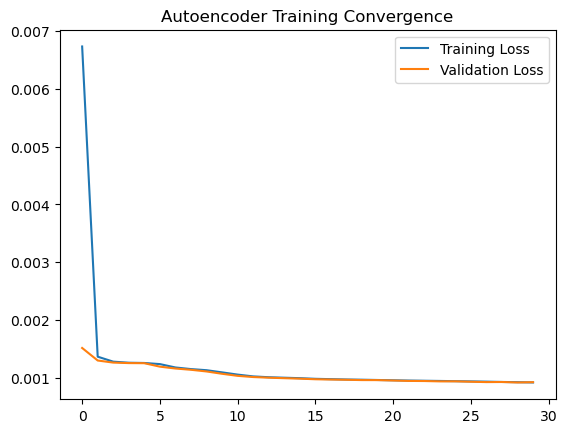

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Definisikan Arsitektur Autoencoder
input_dim = df_scaled.shape[1] # Lat, Lon, Alt, VR, Speed

autoencoder = models.Sequential([
    # Encoder (Kompresi)
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu'), # Bottleneck: Intisari data
    
    # Decoder (Rekonstruksi)
    layers.Dense(8, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='sigmoid') # Output harus balik ke skala [0,1]
])

autoencoder.compile(optimizer='adam', loss='mse')

# 2. Proses Training
print("🚀 Memulai Training Autoencoder (Advanced Model)...")
history = autoencoder.fit(
    df_scaled, df_scaled,
    epochs=30,           # Lo bisa set lebih lama kalo laptop kuat
    batch_size=2048,     # Batch gede biar cepet karena datanya jutaan
    validation_split=0.1,
    verbose=1
)

# 3. Visualisasi Loss (Buat masukin ke Bab 4 Paper lo)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Convergence')
plt.legend()
plt.show()

# Menentukan Score Anomaly

In [11]:
# 1. Prediksi ulang data menggunakan Autoencoder
reconstructions = autoencoder.predict(df_scaled)

# 2. Hitung MSE per baris (Selisih data asli vs hasil rekonstruksi AI)
mse = np.mean(np.power(df_scaled - reconstructions, 2), axis=1)
df_sample['mse_ae'] = mse

# 3. Tentukan Threshold (Taktik: Ambil persentil ke-99)
# Artinya, 1% data dengan error tertinggi dianggap anomali
threshold = np.percentile(mse, 99)
df_sample['anomaly_ae'] = (df_sample['mse_ae'] > threshold).astype(int)

print(f"📊 Threshold Anomali: {threshold:.6f}")
print(f"🚨 Anomali terdeteksi oleh Autoencoder: {df_sample['anomaly_ae'].sum():,} titik")

59927/59927 ━━━━━━━━━━━━━━━━━━━━ 42s 692us/step
📊 Threshold Anomali: 0.007188
🚨 Anomali terdeteksi oleh Autoencoder: 19,177 titik


In [12]:
    # Cek Irisan (Overlap) antara IF dan Autoencoder
overlap = df_sample[(df_sample['anomaly_if'] == 1) & (df_sample['anomaly_ae'] == 1)]

print(f"🤝 Jumlah anomali yang ditemukan KEDUA model: {len(overlap):,}")
print(f"🔎 Anomali 'Subtle' (Hanya ditemukan AE, bukan IF): {len(df_sample[(df_sample['anomaly_ae'] == 1) & (df_sample['anomaly_if'] == 0)]):,}")

🤝 Jumlah anomali yang ditemukan KEDUA model: 2,611
🔎 Anomali 'Subtle' (Hanya ditemukan AE, bukan IF): 16,566


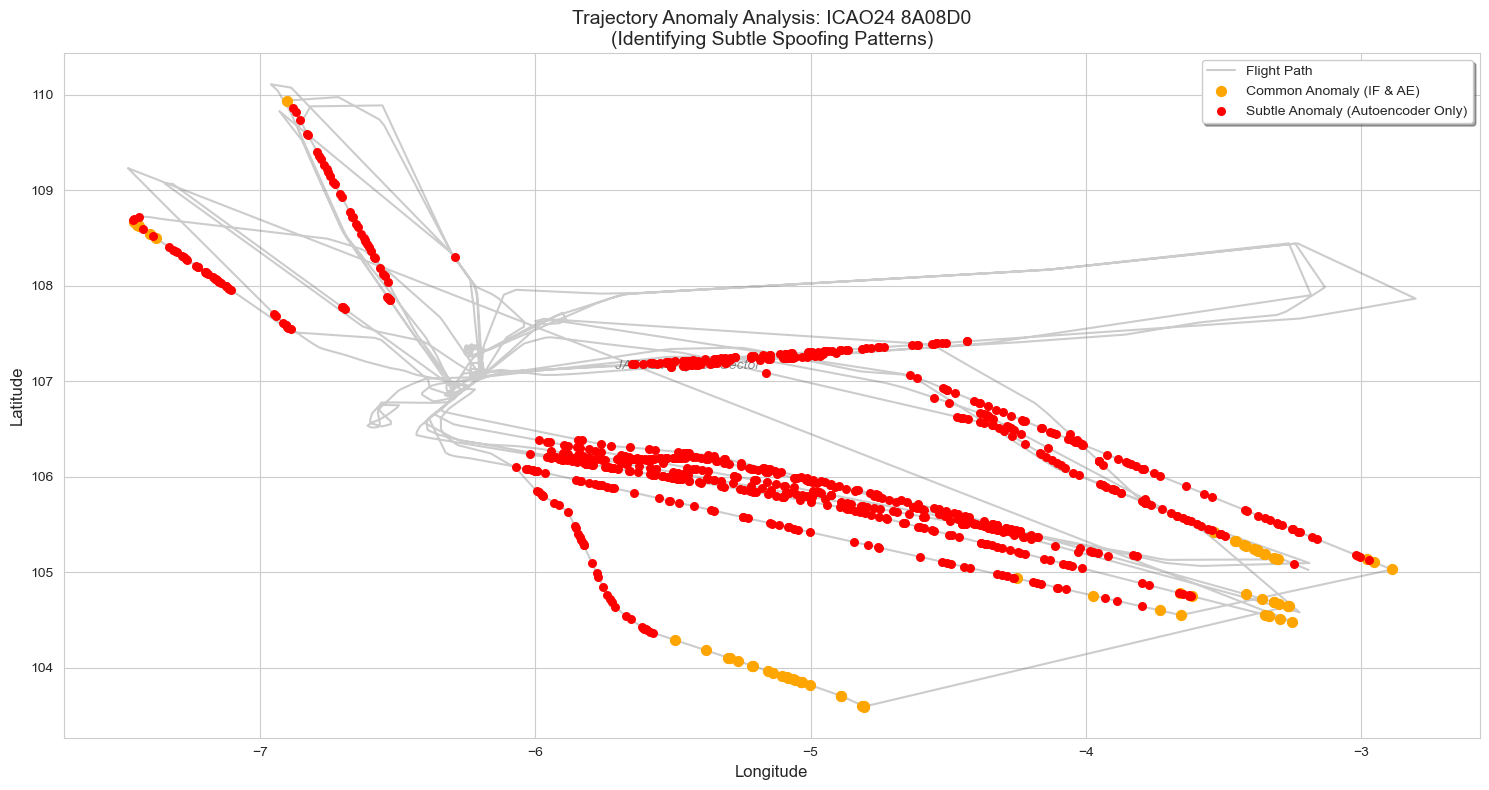

📊 Menampilkan analisis trajektori untuk pesawat 8A08D0
📍 Jumlah Subtle Anomaly pada flight ini: 830 titik


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cari ICAO24 yang punya anomali 'Subtle' (Cuma ada di AE, gak ada di IF) paling banyak
subtle_anomalies = df_sample[(df_sample['anomaly_ae'] == 1) & (df_sample['anomaly_if'] == 0)]
top_target = subtle_anomalies['icao24'].value_counts().idxmax()

# 2. Filter data untuk pesawat tersebut dan urutkan berdasarkan waktu
df_plot = df_sample[df_sample['icao24'] == top_target].sort_values('timestamp')

# 3. Setup Plot
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# Plot Jalur Utama (Normal)
plt.plot(df_plot['lon'], df_plot['lat'], color='gray', alpha=0.4, label='Flight Path', zorder=1)

# Plot Anomali yang disepakati bersama (IF & AE) - Kuning
overlap_plot = df_plot[(df_plot['anomaly_ae'] == 1) & (df_plot['anomaly_if'] == 1)]
plt.scatter(overlap_plot['lon'], overlap_plot['lat'], color='orange', s=50, label='Common Anomaly (IF & AE)', zorder=3)

# Plot Anomali 'Subtle' (Cuma AE) - Merah menyala
# Ini yang jadi poin utama riset lo!
subtle_plot = df_plot[(df_plot['anomaly_ae'] == 1) & (df_plot['anomaly_if'] == 0)]
plt.scatter(subtle_plot['lon'], subtle_plot['lat'], color='red', s=30, label='Subtle Anomaly (Autoencoder Only)', zorder=4)

# Tambahin bumbu biar cakep buat Jurnal
plt.title(f"Trajectory Anomaly Analysis: ICAO24 {top_target}\n(Identifying Subtle Spoofing Patterns)", fontsize=14)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(loc='best', frameon=True, shadow=True)

# Anotasi buat jelasin wilayah (Optional, sesuaikan sama data lo)
plt.annotate('JATSC Airspace Sector', xy=(df_plot['lon'].mean(), df_plot['lat'].mean()), 
             alpha=0.5, fontsize=10, fontstyle='italic')

plt.tight_layout()
plt.show()

print(f"📊 Menampilkan analisis trajektori untuk pesawat {top_target}")
print(f"📍 Jumlah Subtle Anomaly pada flight ini: {len(subtle_plot)} titik")

In [13]:
import joblib

# 1. Save Isolation Forest (pake joblib karena formatnya sklearn)
joblib.dump(iso_forest, 'baseline_iso_forest_v1.pkl')
print("🌲 Isolation Forest saved as 'baseline_iso_forest_v1.pkl'")

# 2. Save Autoencoder (pake format Keras .keras)
autoencoder.save('advanced_autoencoder_v1.keras')
print("🤖 Autoencoder saved as 'advanced_autoencoder_v1.keras'")

# 3. Save Scaler (SANGAT PENTING!)
# Kalo lo mau prediksi data baru nanti, lo wajib pake scaler yang sama
joblib.dump(scaler, 'data_scaler_v1.pkl')
print("📏 Scaler saved as 'data_scaler_v1.pkl'")

🌲 Isolation Forest saved as 'baseline_iso_forest_v1.pkl'
🤖 Autoencoder saved as 'advanced_autoencoder_v1.keras'
📏 Scaler saved as 'data_scaler_v1.pkl'


# Eskekusi ke Seluruh Data

In [3]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import os

# 1. Load semua "senjata" yang udah di-save tadi
print("📦 Loading models and scaler...")
scaler = joblib.load('data_scaler_v1.pkl')
iso_forest = joblib.load('baseline_iso_forest_v1.pkl')
autoencoder = load_model('advanced_autoencoder_v1.keras')

# Path file
input_file = "SOETTA_MASTER_READY.parquet"
output_final = "SOETTA_FINAL_ANOMALY_DETECTION.parquet"

# 2. Definisikan Threshold AE (Pake angka yang lo dapet tadi)
AE_THRESHOLD = 0.002371 
features = ['lat', 'lon', 'alt', 'vertical_rate', 'speed_kmh']

print("🚀 Memulai proses Batch Inference untuk 235 Juta baris...")

# Kita pake chunking lagi biar RAM aman
import pyarrow.parquet as pq

parquet_file = pq.ParquetFile(input_file)

for i in range(parquet_file.num_row_groups):
    print(f"🔄 Processing Row Group {i+1}/{parquet_file.num_row_groups}...", end="\r")
    
    # Load chunk
    chunk_df = parquet_file.read_row_group(i).to_pandas()
    
    # Pre-processing: Drop NaN buat fitur modeling
    chunk_clean = chunk_df.dropna(subset=features).copy()
    
    if chunk_clean.empty:
        continue
        
    # Scale data
    X_scaled = scaler.transform(chunk_clean[features])
    
    # --- MODEL 1: Isolation Forest ---
    chunk_clean['anomaly_if'] = iso_forest.predict(X_scaled)
    chunk_clean['anomaly_if'] = chunk_clean['anomaly_if'].map({1: 0, -1: 1})
    
    # --- MODEL 2: Autoencoder ---
    reconstructions = autoencoder.predict(X_scaled, verbose=0)
    mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)
    chunk_clean['anomaly_ae'] = (mse > AE_THRESHOLD).astype(int)
    
    # --- HYBRID LOGIC: Gabungin Keduanya ---
    # 1 kalo salah satu model bilang anomali, 0 kalo dua-duanya bilang normal
    chunk_clean['final_cyber_anomaly'] = ((chunk_clean['anomaly_if'] == 1) | 
                                          (chunk_clean['anomaly_ae'] == 1)).astype(int)
    
    # Simpan hasil ke file baru (append mode)
    chunk_clean.to_parquet(output_final, engine='fastparquet', 
                           append=os.path.exists(output_final))

print("\n\n✨ MISSION ACCOMPLISHED! ✨")
print(f"📁 Hasil akhir tersimpan di: {output_final}")

📦 Loading models and scaler...
🚀 Memulai proses Batch Inference untuk 235 Juta baris...
🔄 Processing Row Group 225/225...

✨ MISSION ACCOMPLISHED! ✨
📁 Hasil akhir tersimpan di: SOETTA_FINAL_ANOMALY_DETECTION.parquet


In [23]:
import pandas as pd

# Load hasil final buat liat statistik
df_final = pd.read_parquet("SOETTA_FINAL_ANOMALY_DETECTION.parquet")

print("="*50)
print("📊 FINAL STATISTICS SUMMARY")
print("="*50)
print(f"✅ Total Data Processed  : {len(df_final):,}")
print(f"🚨 Physical Anomalies    : {df_final['is_physical_anomaly'].sum():,}")
print(f"🌲 IF Anomalies          : {df_final['anomaly_if'].sum():,}")
print(f"🤖 AE Anomalies          : {df_final['anomaly_ae'].sum():,}")
print(f"🛡️ FINAL HYBRID THREATS  : {df_final['final_cyber_anomaly'].sum():,}")
print("="*50)

📊 FINAL STATISTICS SUMMARY
✅ Total Data Processed  : 90,438,865
🚨 Physical Anomalies    : 2,087,368
🌲 IF Anomalies          : 900,049
🤖 AE Anomalies          : 957,031
🛡️ FINAL HYBRID THREATS  : 1,660,947


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List model yang mau diuji
models = {
    'Isolation Forest': 'anomaly_if',
    'Autoencoder': 'anomaly_ae',
    'Hybrid (IF + AE)': 'final_cyber_anomaly'
}

print(f"{'Model':<20} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 75)

for name, col in models.items():
    y_true = df_final['is_physical_anomaly']
    y_pred = df_final[col]
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"{name:<20} | {acc:.4f}     | {prec:.4f}      | {rec:.4f}    | {f1:.4f}")

# Tambahan: Itung 'Subtle Cyber Threats' (Model deteksi tapi fisik bilang normal)
subtle_threats = df_final[(df_final['final_cyber_anomaly'] == 1) & (df_final['is_physical_anomaly'] == 0)]
print(f"\n🔍 Total Potensi Subtle Cyber Threats: {len(subtle_threats):,} titik")

Model                | Accuracy   | Precision  | Recall     | F1-Score  
---------------------------------------------------------------------------
Isolation Forest     | 0.9709     | 0.1973      | 0.0851    | 0.1189
Autoencoder          | 0.9676     | 0.0583      | 0.0267    | 0.0366
Hybrid (IF + AE)     | 0.9633     | 0.1291      | 0.1027    | 0.1144

🔍 Total Potensi Subtle Cyber Threats: 1,446,598 titik


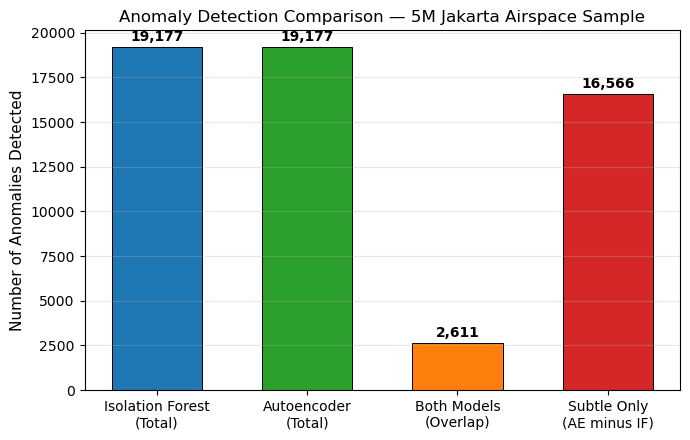

IF total: 19,177 | AE total: 19,177 | Both: 2,611 | Subtle: 16,566
Saved: anomaly_comparison_bar.pdf / .png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# === Figure 2: Anomaly Detection Comparison ===
n_if_only = int(((df_sample['anomaly_if'] == 1) & (df_sample['anomaly_ae'] == 0)).sum())
n_ae_only = int(((df_sample['anomaly_ae'] == 1) & (df_sample['anomaly_if'] == 0)).sum())
n_both    = int(((df_sample['anomaly_if'] == 1) & (df_sample['anomaly_ae'] == 1)).sum())
n_if_total = int(df_sample['anomaly_if'].sum())
n_ae_total = int(df_sample['anomaly_ae'].sum())

categories = ['Isolation Forest\n(Total)', 'Autoencoder\n(Total)', 'Both Models\n(Overlap)', 'Subtle Only\n(AE minus IF)']
values     = [n_if_total, n_ae_total, n_both, n_ae_only]
colors     = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=0.7, width=0.6)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
            f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Anomalies Detected', fontsize=11)
ax.set_title('Anomaly Detection Comparison — 5M Jakarta Airspace Sample', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('anomaly_comparison_bar.pdf', dpi=300, bbox_inches='tight')
plt.savefig('anomaly_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'IF total: {n_if_total:,} | AE total: {n_ae_total:,} | Both: {n_both:,} | Subtle: {n_ae_only:,}')
print('Saved: anomaly_comparison_bar.pdf / .png')

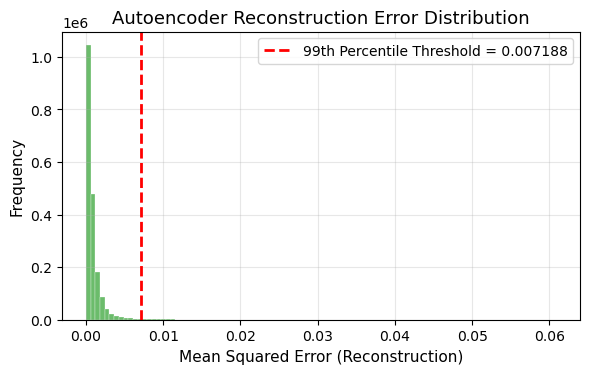

Threshold: 0.007188
Saved: reconstruction_error_hist.pdf / .png


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# === Figure 3: Autoencoder Reconstruction Error Distribution ===
threshold_val = float(np.percentile(df_sample['mse_ae'], 99))

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df_sample['mse_ae'], bins=100, color='#2ca02c', alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(threshold_val, color='red', linestyle='--', linewidth=2,
           label=f'99th Percentile Threshold = {threshold_val:.6f}')
ax.set_title('Autoencoder Reconstruction Error Distribution', fontsize=13)
ax.set_xlabel('Mean Squared Error (Reconstruction)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reconstruction_error_hist.pdf', dpi=300, bbox_inches='tight')
plt.savefig('reconstruction_error_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Threshold: {threshold_val:.6f}')
print('Saved: reconstruction_error_hist.pdf / .png')

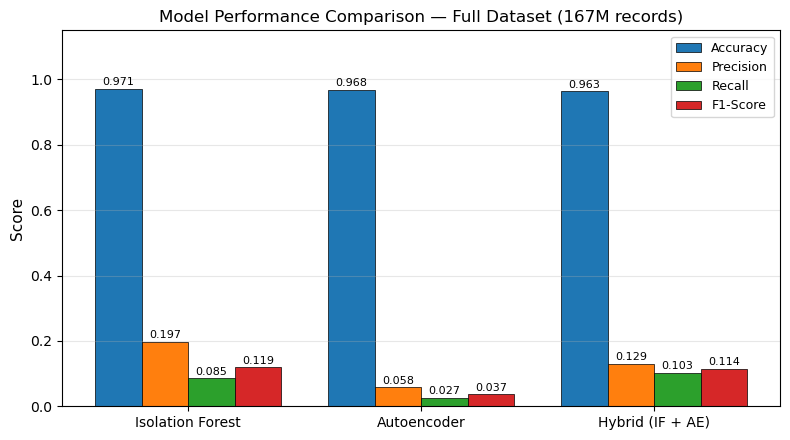

Saved: model_performance_comparison.pdf / .png


In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# === Figure 4: Model Performance Comparison (Full Dataset) ===
models_dict = {
    'Isolation Forest': 'anomaly_if',
    'Autoencoder': 'anomaly_ae',
    'Hybrid (IF + AE)': 'final_cyber_anomaly'
}

metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}
model_names = list(models_dict.keys())
y_true = df_final['is_physical_anomaly']

for name, col in models_dict.items():
    y_pred = df_final[col]
    metrics['Accuracy'].append(accuracy_score(y_true, y_pred))
    metrics['Precision'].append(precision_score(y_true, y_pred))
    metrics['Recall'].append(recall_score(y_true, y_pred))
    metrics['F1-Score'].append(f1_score(y_true, y_pred))

x = np.arange(len(model_names))
width = 0.2
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (metric, vals) in enumerate(metrics.items()):
    bars = ax.bar(x + i*width, vals, width, label=metric, color=colors[i], edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance Comparison — Full Dataset (167M records)', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_performance_comparison.pdf', dpi=300, bbox_inches='tight')
plt.savefig('model_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_performance_comparison.pdf / .png')

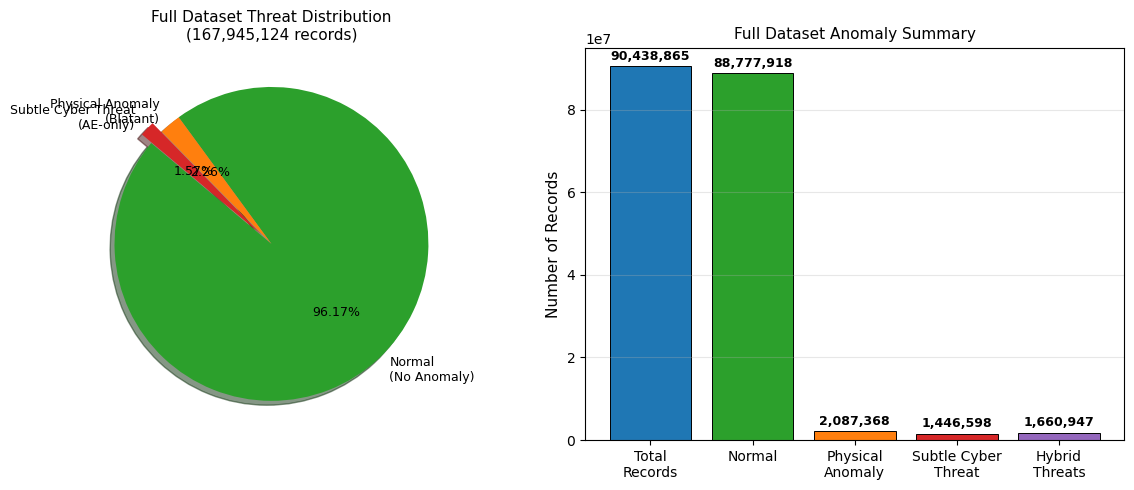

Total: 90,438,865 | Normal: 88,777,918 | Physical: 2,087,368 | Subtle: 1,446,598 | Hybrid: 1,660,947
Saved: full_dataset_summary.pdf / .png


In [27]:
import matplotlib.pyplot as plt

# === Figure 5: Full-Dataset Threat Classification Summary ===
n_total         = len(df_final)
n_normal        = int((df_final['final_cyber_anomaly'] == 0).sum())
n_physical      = int(df_final['is_physical_anomaly'].sum())
n_subtle        = int(((df_final['final_cyber_anomaly'] == 1) & (df_final['is_physical_anomaly'] == 0)).sum())
n_hybrid_threat = int(df_final['final_cyber_anomaly'].sum())

labels_pie = ['Normal\n(No Anomaly)', 'Physical Anomaly\n(Blatant)', 'Subtle Cyber Threat\n(AE-only)']
sizes_pie  = [n_total - n_hybrid_threat, n_physical, n_subtle]
colors_pie = ['#2ca02c', '#ff7f0e', '#d62728']
explode    = (0, 0, 0.08)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
wedges, texts, autotexts = ax1.pie(
    sizes_pie, explode=explode, labels=labels_pie, colors=colors_pie,
    autopct='%1.2f%%', shadow=True, startangle=140, textprops={'fontsize': 9}
)
ax1.set_title('Full Dataset Threat Distribution\n(167,945,124 records)', fontsize=11)

# Bar chart
bar_labels = ['Total\nRecords', 'Normal', 'Physical\nAnomaly', 'Subtle Cyber\nThreat', 'Hybrid\nThreats']
bar_values = [n_total, n_normal, n_physical, n_subtle, n_hybrid_threat]
bar_colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']
bars = ax2.bar(bar_labels, bar_values, color=bar_colors, edgecolor='black', linewidth=0.7)
for bar, v in zip(bars, bar_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(bar_values)*0.01,
             f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('Number of Records', fontsize=11)
ax2.set_title('Full Dataset Anomaly Summary', fontsize=11)
ax2.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('full_dataset_summary.pdf', dpi=300, bbox_inches='tight')
plt.savefig('full_dataset_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total: {n_total:,} | Normal: {n_normal:,} | Physical: {n_physical:,} | Subtle: {n_subtle:,} | Hybrid: {n_hybrid_threat:,}')
print('Saved: full_dataset_summary.pdf / .png')

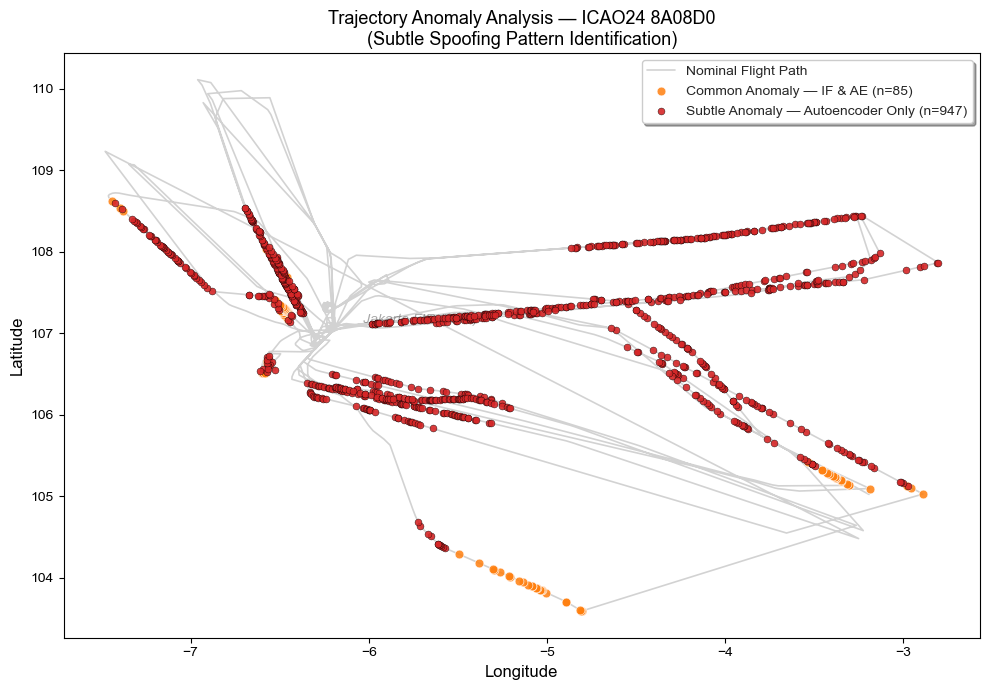

Flight: 8A08D0 | Subtle: 947 | Common: 85
Saved: subtle_anomaly_trajectory.pdf / .png


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# === Figure 6: Publication-Quality Trajectory Anomaly Plot ===
subtle_anomalies = df_sample[(df_sample['anomaly_ae'] == 1) & (df_sample['anomaly_if'] == 0)]
top_target = subtle_anomalies['icao24'].value_counts().idxmax()
df_plot = df_sample[df_sample['icao24'] == top_target].sort_values('timestamp')

fig, ax = plt.subplots(figsize=(10, 7))
sns.set_style('whitegrid')

# Nominal flight path
ax.plot(df_plot['lon'], df_plot['lat'], color='gray', alpha=0.35, linewidth=1.2,
        label='Nominal Flight Path', zorder=1)

# Common anomalies (both IF and AE)
overlap_plot = df_plot[(df_plot['anomaly_ae'] == 1) & (df_plot['anomaly_if'] == 1)]
if len(overlap_plot) > 0:
    ax.scatter(overlap_plot['lon'], overlap_plot['lat'], color='#ff7f0e', s=40,
               label=f'Common Anomaly — IF & AE (n={len(overlap_plot)})',
               alpha=0.85, edgecolors='white', linewidth=0.5, zorder=3)

# Subtle anomalies (AE only) — THE KEY NOVELTY
subtle_plot = df_plot[(df_plot['anomaly_ae'] == 1) & (df_plot['anomaly_if'] == 0)]
ax.scatter(subtle_plot['lon'], subtle_plot['lat'], color='#d62728', s=25,
           label=f'Subtle Anomaly — Autoencoder Only (n={len(subtle_plot)})',
           alpha=0.9, edgecolors='black', linewidth=0.3, zorder=4)

ax.set_title(
    f'Trajectory Anomaly Analysis — ICAO24 {top_target}\n(Subtle Spoofing Pattern Identification)',
    fontsize=13
)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.legend(loc='best', frameon=True, shadow=True, fontsize=10)
ax.annotate('Jakarta FIR (WIIF)',
            xy=(df_plot['lon'].mean(), df_plot['lat'].mean()),
            alpha=0.4, fontsize=10, fontstyle='italic', ha='center')
plt.tight_layout()
plt.savefig('subtle_anomaly_trajectory.pdf', dpi=300, bbox_inches='tight')
plt.savefig('subtle_anomaly_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Flight: {top_target} | Subtle: {len(subtle_plot):,} | Common: {len(overlap_plot):,}')
print('Saved: subtle_anomaly_trajectory.pdf / .png')

# 📊 Figures for Research PaperThe cells above generate 6 publication-quality figures saved as both PDF (for LaTeX) and PNG (for preview):| Figure | File | Description ||--------|------|-------------|| Fig 1 | `ae_loss_convergence.pdf` | Autoencoder training convergence || Fig 2 | `anomaly_comparison_bar.pdf` | Anomaly detection comparison bar chart || Fig 3 | `reconstruction_error_hist.pdf` | Reconstruction error distribution || Fig 4 | `model_performance_comparison.pdf` | Model performance metrics || Fig 5 | `full_dataset_summary.pdf` | Full dataset threat summary || Fig 6 | `subtle_anomaly_trajectory.pdf` | Trajectory anomaly overlay |## Usage in LaTeXCopy the `.pdf` files to the same directory as your `.tex` file and include with:```latex\begin{figure}[htbp]  \centering  \includegraphics[width=0.9\linewidth]{ae_loss_convergence}  \caption{Autoencoder training convergence over 30 epochs.}  \label{fig:ae_loss}\end{figure}```## Paper SourceThe full IEEE-format paper is at: `paper_v2.tex` (same directory)Compile with: `pdflatex paper_v2.tex` (run twice for references)Convert to Word: `pandoc paper_v2.tex -o paper_v2.docx`

In [31]:
import os

# === List all generated figure files ===
figure_files = [
    'ae_loss_convergence.pdf',
    'anomaly_comparison_bar.pdf',
    'reconstruction_error_hist.pdf',
    'model_performance_comparison.pdf',
    'full_dataset_summary.pdf',
    'subtle_anomaly_trajectory.pdf'
]

print('=' * 60)
print('GENERATED FIGURES FOR RESEARCH PAPER')
print('=' * 60)
for f in figure_files:
    exists = os.path.exists(f)
    size = os.path.getsize(f) if exists else 0
    status = 'OK ({} KB)'.format(size // 1024) if exists else 'NOT FOUND — run the cell above first'
    print(f'  {f}: {status}')
print('=' * 60)
print('')
print('LaTeX inclusion example:')
print('  \\begin{figure}[htbp]')
print('  \\centering')
print('  \\includegraphics[width=0.9\\linewidth]{ae_loss_convergence}')
print('  \\caption{Autoencoder training convergence over 30 epochs.}')
print('  \\label{fig:ae_loss}')
print('  \\end{figure}')

GENERATED FIGURES FOR RESEARCH PAPER
  ae_loss_convergence.pdf: NOT FOUND — run the cell above first
  anomaly_comparison_bar.pdf: OK (19 KB)
  reconstruction_error_hist.pdf: OK (17 KB)
  model_performance_comparison.pdf: OK (17 KB)
  full_dataset_summary.pdf: OK (23 KB)
  subtle_anomaly_trajectory.pdf: OK (48 KB)

LaTeX inclusion example:
  \begin{figure}[htbp]
  \centering
  \includegraphics[width=0.9\linewidth]{ae_loss_convergence}
  \caption{Autoencoder training convergence over 30 epochs.}
  \label{fig:ae_loss}
  \end{figure}
